# Phase 1 — Data Preparation & Preprocessing

**Tujuan**: ekstrak frame dari setiap video Celeb-DF v2, deteksi wajah dengan MTCNN, lakukan *similarity transform alignment* ke template ArcFace 5-titik, dan simpan crop wajah 112x112 ke folder `processed_faces/{train,test}/{real,fake}/`.

**Catatan split**:
- Test split mengikuti `List_of_testing_videos.txt` resmi Celeb-DF (340 fake + 108 real, label `1 path` = real, `0 path` = fake).
- `YouTube-real/` di-skip seluruhnya (tidak relevan untuk perbandingan backbone wajah selebriti).
- Train fake (5299 video) di-subsample agar seimbang dengan train real (482 video).

In [1]:
import random
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import torch
from PIL import Image
from skimage.transform import SimilarityTransform
from tqdm.notebook import tqdm

# ---- Konfigurasi ----
ROOT = Path('C:/Users/User/Documents/Computer_Pision')
DIR_REAL = ROOT / 'Celeb-real'
DIR_FAKE = ROOT / 'Celeb-synthesis'
TEST_LIST = ROOT / 'List_of_testing_videos.txt'
OUTPUT_DIR = ROOT / 'processed_faces'

NUM_FRAMES_PER_VIDEO = 10        # sesuai context.md: 10-15 frame
FACE_SIZE = 112                  # input standar ArcFace / AdaFace / TransFace
MIN_FACE_CONFIDENCE = 0.90
MAX_FAKE_TRAIN_VIDEOS = 500      # subsample fake-train agar balanced dgn real-train
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device       : {DEVICE}')
print(f'Output dir   : {OUTPUT_DIR}')
print(f'Frames/video : {NUM_FRAMES_PER_VIDEO}')

Device       : cuda
Output dir   : C:\Users\User\Documents\Computer_Pision\processed_faces
Frames/video : 10


## 1) Build video manifest (train/test x real/fake)

In [2]:
test_paths = set()
with open(TEST_LIST, 'r') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        _label, rel = line.split(' ', 1)
        # gunakan forward slash agar match dgn rel kita di bawah
        test_paths.add(rel.replace('\\', '/'))

def make_rows(folder: Path, class_label: int, class_name: str):
    rows = []
    for video in sorted(folder.glob('*.mp4')):
        rel = f'{folder.name}/{video.name}'
        split = 'test' if rel in test_paths else 'train'
        rows.append({
            'video': str(video),
            'rel'  : rel,
            'label': class_label,    # 0 = real, 1 = fake
            'class': class_name,
            'split': split,
        })
    return rows

rows = make_rows(DIR_REAL, 0, 'real') + make_rows(DIR_FAKE, 1, 'fake')
manifest = pd.DataFrame(rows)
print('Distribusi video:')
print(manifest.groupby(['split', 'class']).size().unstack(fill_value=0))

Distribusi video:
class  fake  real
split            
test    340   108
train  5299   482


In [3]:
# Subsample fake-train agar balanced dengan real-train
real_train = manifest[(manifest['split'] == 'train') & (manifest['class'] == 'real')]
fake_train = manifest[(manifest['split'] == 'train') & (manifest['class'] == 'fake')]
test_set   = manifest[manifest['split'] == 'test']

target_n = min(MAX_FAKE_TRAIN_VIDEOS, len(real_train), len(fake_train))
real_train_sel = real_train.sample(n=min(len(real_train), target_n), random_state=RANDOM_SEED)
fake_train_sel = fake_train.sample(n=target_n, random_state=RANDOM_SEED)

selected = pd.concat([real_train_sel, fake_train_sel, test_set], ignore_index=True)
print('Distribusi video terpilih:')
print(selected.groupby(['split', 'class']).size().unstack(fill_value=0))
print(f'Total video terpilih: {len(selected)}')

Distribusi video terpilih:
class  fake  real
split            
test    340   108
train   482   482
Total video terpilih: 1412


## 2) Inisialisasi MTCNN face detector

In [4]:
from facenet_pytorch import MTCNN

mtcnn = MTCNN(
    image_size=FACE_SIZE,
    keep_all=False,        # cukup ambil 1 wajah utama per frame
    post_process=False,    # alignment custom (similarity transform)
    select_largest=True,   # pilih wajah terbesar (subjek utama)
    device=DEVICE,
)
print('MTCNN siap pada device:', DEVICE)

MTCNN siap pada device: cuda


## 3) Helper functions — frame sampling, detect, align

In [5]:
# Template 5-titik ArcFace untuk 112x112 (standar InsightFace)
ARCFACE_TEMPLATE = np.array([
    [38.2946, 51.6963],   # mata kiri
    [73.5318, 51.5014],   # mata kanan
    [56.0252, 71.7366],   # hidung
    [41.5493, 92.3655],   # mulut kiri
    [70.7299, 92.2041],   # mulut kanan
], dtype=np.float32)

def sample_frame_indices(total_frames: int, n: int):
    if total_frames <= 0:
        return []
    if total_frames <= n:
        return list(range(total_frames))
    return np.linspace(0, total_frames - 1, n, dtype=int).tolist()

def read_sampled_frames(video_path: str, n: int):
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    indices = sample_frame_indices(total, n)
    frames = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ok, frame = cap.read()
        if ok:
            frames.append((idx, frame))   # BGR
    cap.release()
    return frames

def align_face(frame_bgr, landmarks_5pt):
    tform = SimilarityTransform()
    tform.estimate(landmarks_5pt.astype(np.float32), ARCFACE_TEMPLATE)
    M = tform.params[0:2, :]
    return cv2.warpAffine(frame_bgr, M, (FACE_SIZE, FACE_SIZE), borderValue=0.0)

@torch.inference_mode()
def detect_and_align(frame_bgr):
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    pil = Image.fromarray(frame_rgb)
    boxes, probs, landmarks = mtcnn.detect(pil, landmarks=True)
    if boxes is None or landmarks is None:
        return None
    prob = probs[0]
    if prob is None or prob < MIN_FACE_CONFIDENCE:
        return None
    return align_face(frame_bgr, landmarks[0])

## 4) Main loop — process all selected videos

In [6]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
for split in ['train', 'test']:
    for cls in ['real', 'fake']:
        (OUTPUT_DIR / split / cls).mkdir(parents=True, exist_ok=True)

records = []
fail_log = []

for row in tqdm(selected.to_dict('records'), desc='Videos'):
    video_stem = Path(row['video']).stem
    out_dir = OUTPUT_DIR / row['split'] / row['class']

    try:
        frames = read_sampled_frames(row['video'], NUM_FRAMES_PER_VIDEO)
    except Exception as e:
        fail_log.append({'video': row['rel'], 'error': f'read:{e}'})
        continue

    saved = 0
    for frame_idx, frame in frames:
        aligned = detect_and_align(frame)
        if aligned is None:
            continue
        fname = f'{video_stem}_f{frame_idx:04d}.jpg'
        out_path = out_dir / fname
        cv2.imwrite(str(out_path), aligned, [cv2.IMWRITE_JPEG_QUALITY, 95])
        records.append({
            'path'     : str(out_path.relative_to(OUTPUT_DIR)).replace('\\', '/'),
            'video'    : row['rel'],
            'frame_idx': frame_idx,
            'label'    : row['label'],
            'class'    : row['class'],
            'split'    : row['split'],
        })
        saved += 1

    if saved == 0:
        fail_log.append({'video': row['rel'], 'error': 'no_face_detected'})

faces_df = pd.DataFrame(records)
faces_df.to_csv(OUTPUT_DIR / 'faces_manifest.csv', index=False)
print(f'\nTotal face crops disimpan: {len(faces_df)}')
print(faces_df.groupby(['split', 'class']).size().unstack(fill_value=0))

if fail_log:
    pd.DataFrame(fail_log).to_csv(OUTPUT_DIR / 'preprocess_failures.csv', index=False)
    print(f'\nFailures: {len(fail_log)} video (lihat preprocess_failures.csv)')

Videos:   0%|          | 0/1412 [00:00<?, ?it/s]


Total face crops disimpan: 13999
class  fake  real
split            
test   3375  1069
train  4789  4766


## 5) Sanity check — visualisasi sample

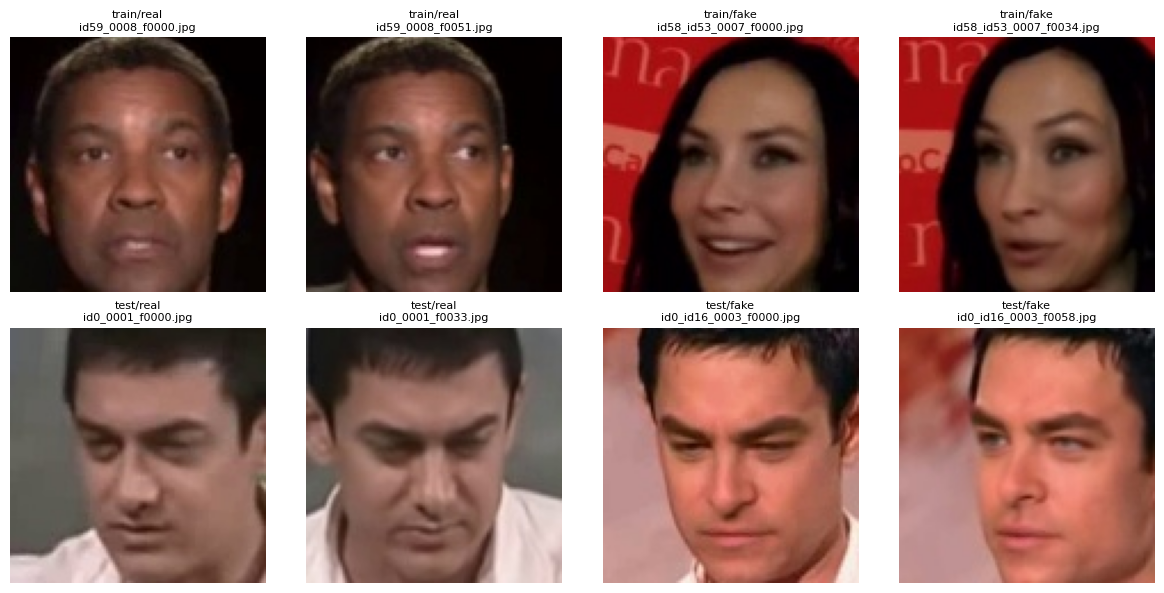

In [7]:
import matplotlib.pyplot as plt

sample = faces_df.groupby(['split', 'class']).head(2).reset_index(drop=True)
n = len(sample)
cols = 4
rows_n = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows_n, cols, figsize=(3 * cols, 3 * rows_n))
axes = np.array(axes).ravel()
for ax, rec in zip(axes, sample.to_dict('records')):
    img = cv2.imread(str(OUTPUT_DIR / rec['path']))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(f"{rec['split']}/{rec['class']}\n{Path(rec['path']).name}", fontsize=8)
    ax.axis('off')
for ax in axes[n:]:
    ax.axis('off')
plt.tight_layout()
plt.show()